Here, we do sims where we change the soil type to keep water more or less.

See the methodology of Brian's team : what soils did they use ? 

UG : Soil water is determined by inputs (precipitation) and outputs (PrecLossFrac, percolation out of the rooting zone (controlled by SoilType) and transpiration). Tuning of soil water is done primarily with PrecLossFrac, LeakageFrac and SoilType, which assumes that transpiration is correct if the photosynthesis and growth behavior is correct. PrecLossFrac typically represents water lost where slope is sufficient for water to run off before it can enter the soil. You should calibrate for a slope condition that is flatter than average in your study area. If you have species that are found only in wetlands, you should calibrate those on a wetland ecoregion, having RunoffCapture and LeakageFrac parameter settings that produce appropriate soil saturation. RunoffCapture represents the maximum depth of standing water across the ecoregion, and LeakageFrac can be used to reflect any impermeable soil layer that reduces drainage. In lieu of empirical data to help set these parameters, tune them such that the species typically found there can survive and the hydrology mimics reality. Species that are found on both upland and lowland sites should be calibrated on both types of sites, focusing on H1 and H2 on lowland sites and H3 and H4 on upland sites.

From reese et al 2024 supp mat A (sturtevant) :

> To assess species-level response to water stress (P 5), we verified that species biomass curves simulated for moderately drained soil (e.g., very fine sandy loam) approximated the 50th percentile productivity curves estimated via FVS-ls, while those simulated for excessively drained soils (e.g., coarse sand) approximated the 5th percentile FVS-ls species biomass curve (Fig. A1). To simulate waterlogging stress, we categorized tree species according to waterlogging tolerance via the TRY database, and then calibrated tree species growth via hydrologic parameters, where intolerant species could not persist, mildly tolerant species could persist at low biomass (e.g., Fig. A1), and tolerant species had reduced growth more consistent with productivity of the 5th percentile FVS-ls species biomass curve.

Follow this methodology; but instead of using percentiles from FVS-ls, use Percentiles from the NFI instead ? But be careful to remove pixels where abundance of the species is way too low ?

Also Reese et al 2024 supp mat A for competition (if we do competition here) :

> P 5. Variation in tree species growth emerges from water stress, in a way that is consistent with the range in tree species productivity documented by FIA. 
a.	Stress-tolerant species have a narrower range in productivity than stress intolerant species, making them less competitive under optimal growing conditions and more competitive under stressed conditions (Smith and Huston 1989).
b.	Lowland sites generally enable water-logging tolerant species to establish and grow while restricting the same processes in water-logging intolerant species.


# Phase 2 💧 : Calibration of the parameters related to drought and waterlogging tolerance

In PnET-Succession, 4 parameters are related to the effect of water in the soils on tree growth : H1, H2, H3 and H4.

These parameters together define a curve relating the pressure head in the soil with the value of fWater, which is the photosythesis reduction factor linked to water. Here is an example from the user guide :

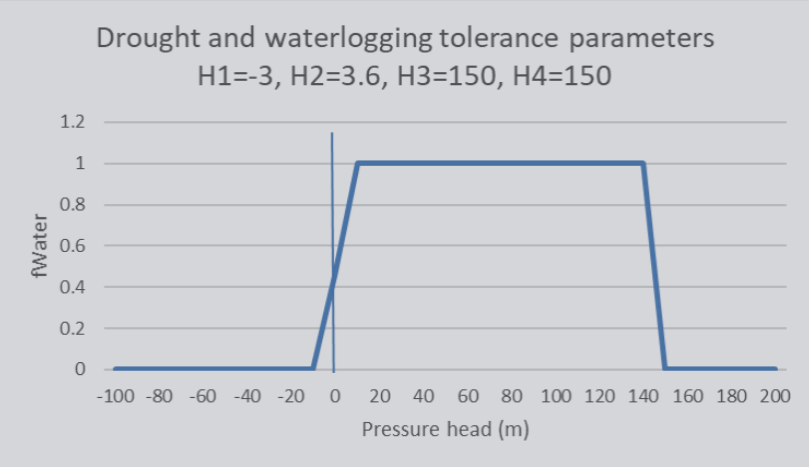

The idea of the trapezoid is that the photosynthesis of tree is overall very little affect by the amount of water present in the soil (fWater = 1, no effect on the photosynthesis); unless we arrive at thresholds of waterlogging or drought (pressure head too small or too high) where the photosynthesis will abruptly diminish. The user guide even recommends to use a value of H3 and H4 (the parameters related to high values of pressure head = drought conditions) to be the same, so that photosynthesis simply stops in drought months.

:::{warning}
Be careful about the signs (positive or negative) used for the pressure head ! I've had a lot of confusion about this.

The pressure head is a measure of water pression in the soil. It represents the following idea : If I put a cylinder in contact with the soil, will it be filled with water because there is so much water in the soil that it wants to get out (pressure, which happens during waterlogging); or will the soil instead "suck" water because it's lacking water (suction, which happens during droughts) ? 

The problem is that normally, a suction normally results in negative values of pressure head (if I had water in my cylinder, the water would go down in the soils); while pressure results in positive values (if the water pushes up into the cylinder because of pressure, how much does it pushes up ?). Pressure head is therefore the measurement, in units of distance, of how up or down the water goes when put in contact with the soil.

But in PnET-Succession, the sign convention is reversed by using the "absolute" values of pressure head. What that means is that in the case of PnET-Succession, the higher the pressure head, the more we are in drought; and vice-versa. As such, the drought parameters H3 and H4 often have positive values above 100; while the waterlogging parameters H1 and H3 are often near 0, or even negative. Keep that in mind !
:::

We sadly lack empirical data to get good estimates of these 4 parameters, and even more for many species. Although [Gustafson et al. 2025](https://bg.copernicus.org/articles/22/2499/2025/) tried to use empirical/experimental data to derive values of H1 and H2 (waterlogging).

This means that we need to calibrate, or at least make a choice about the value of these parameters.

## The different options for calibration

### Option 1 : Using parameters form previous studies

We can simply create a regression (linear or non-linear) of the score of Drought and Waterlogging tolerance acquired from [Niinemets and Valladares 2006](https://onlinelibrary.wiley.com/doi/abs/10.1890/0012-9615%282006%29076%5B0521%3ATTSDAW%5D2.0.CO%3B2) and previously published parameters (i.e. those the [user guide of PnET-Succession](./ReferencesAndData/Documentation/Gustafson2024PnETUserGuide.pdf), including those of [Gustafson et al. 2025](https://bg.copernicus.org/articles/22/2499/2025/) which have been derived from an empiical experiment. This is quick and easy, and will make sure that we use parameters similar to previous studies.

The default of this approach is that we don't do any calibration, and just re-use what have been done before. It's also deeply reliant on the hypothesis that these parameters are completly dependant on a measure as fuzzy as the "drought tolerance" or "waterlogging tolerance" of a give tree species. It also will not produce parameters that are in any way contextual to our landscape (soils, precipitations, water in the soils); we just have to hope that the model will produce soil water content that make sense for our landscape (although this can be explored).

### Option 2 : Using the method from Sturtevant et al.

The method is described in supp. material of [Reese et al. 2024](https://cdnsciencepub.com/doi/10.1139/cjfr-2024-0085) : 

> To assess species-level response to water stress (P 5), we verified that species biomass curves simulated for moderately drained soil (e.g., very fine sandy loam) approximated the 50th percentile productivity curves estimated via FVS-ls, while those simulated for excessively drained soils (e.g., coarse sand) approximated the 5th percentile FVS-ls species biomass curve (Fig. A1). To simulate waterlogging stress, we categorized tree species according to waterlogging tolerance via the TRY database, and then calibrated tree species growth via hydrologic parameters, where intolerant species could not persist, mildly tolerant species could persist at low biomass (e.g., Fig. A1), and tolerant species had reduced growth more consistent with productivity of the 5th percentile FVS-ls species biomass curve.

We could get the 50th and 5th percentile curves through the functions of Notebook 4, and do a similar experiment using the climate and soils found in the study area. This will make the parameters we derive from this more contextual to our landscape. 

The con is that the approach is quite arbitrary, choosing to lower growth by a certain amount on certain soils. It will ensure a reduced growth where there is less water in soils; but "how much" of a reduction will be quite arbitrary. It will also be a bit longuer to do.

### Options 3 : more research needed ?

There might be other opportunities or methodologies to calibrate these parameters properly that will still require a reasonable amount of time, while still allowing to calibrate many different tree species (i.e. the data we'll be using will be available for many species or locations). I haven't found anything satisfying for now, and am limited by time.

See Notebook 100 for future possible directions that I've highlighted when doing a bit of research.

## Going with option 1 (using regression on previously published parameters)

As I'm quite short on time to finish this calibration, I'm starting with Option 1 for now. 

To do this regression, I'm using the parameters shown in the [user guide of PnET-Succession](./ReferencesAndData/Documentation/Gustafson2024PnETUserGuide.pdf), at the very end. These parameters have been made by Eric Gustafson; as Eric is one of the more knowledgeable person about the model, and because the outputs of this regression match pretty nicely with his calibration tips, I will say that this will do for now.

The following function takes care of making a regression for each parameters versus the Drought tolerance or Waterlogging tolerance value of [Niinemets and Valladares 2006](https://onlinelibrary.wiley.com/doi/abs/10.1890/0012-9615%282006%29076%5B0521%3ATTSDAW%5D2.0.CO%3B2) for the species. The values are in a .csv file containing the parameters from the user guide, with the added values of drought and waterlogging tolerance from [Niinemets and Valladares 2006](https://onlinelibrary.wiley.com/doi/abs/10.1890/0012-9615%282006%29076%5B0521%3ATTSDAW%5D2.0.CO%3B2) added to every species.

If you want to see the quality of the regression, set the parameters of plotting and summaries of the model to `True`. The R2 of the model are pretty good, and the results from the regression follows the rules of Eric pretty well.

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


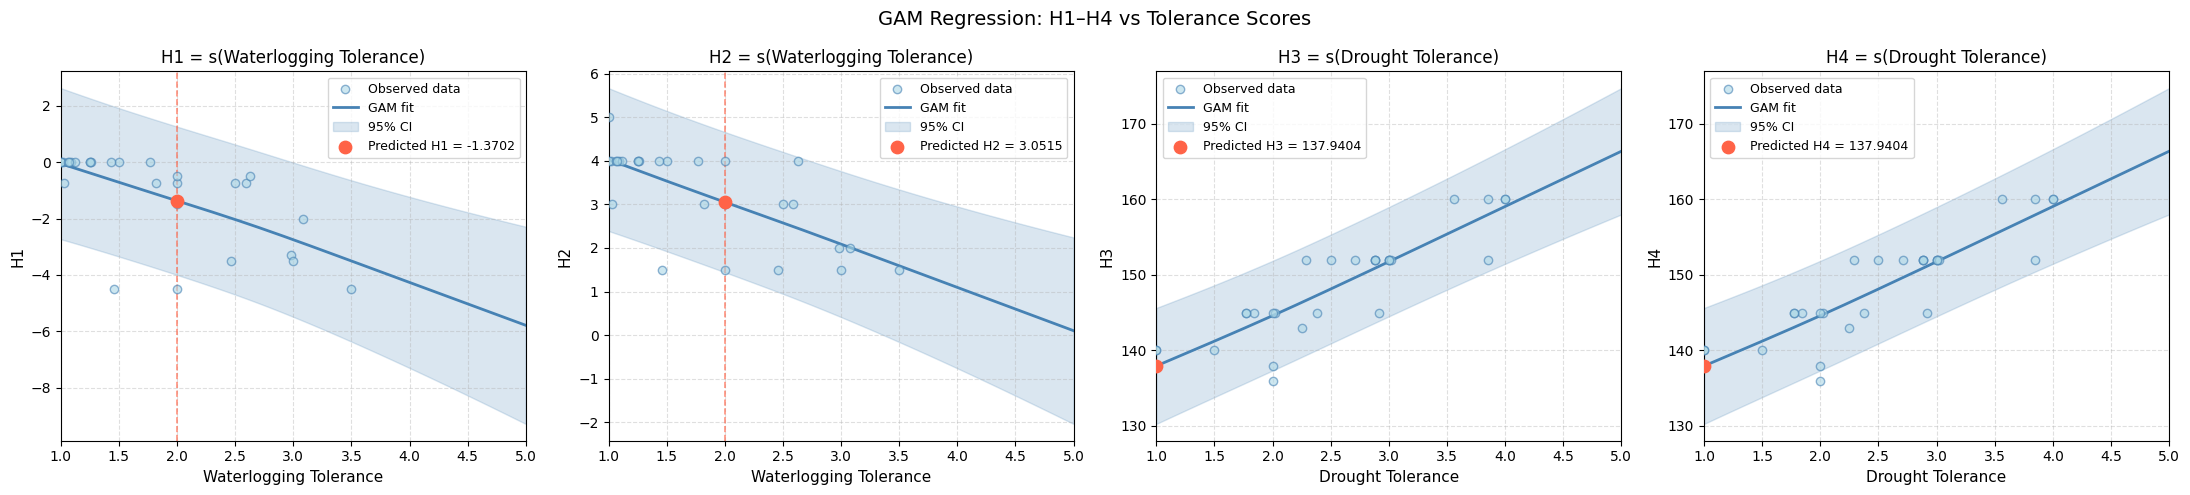

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


In [28]:
from functionsForCalibration import *

resultDict = {}

resultDict["ABIE.BAL"] = predict_H_parameters(
    drought_tolerance=1,
    waterlogging_tolerance=2,
    plot=True,
    gam_summary=False
)

resultDict["ACER.RUB"] = predict_H_parameters(
    drought_tolerance=1.84,
    waterlogging_tolerance=3.08,
    plot=False,
    gam_summary=False
)

resultDict["PICE.MAR"] = predict_H_parameters(
    drought_tolerance=2,
    waterlogging_tolerance=2,
    plot=False,
    gam_summary=False
)

# Re-writing parameter dicts
dictOfInitialCoreSpeciesParameters = json.load(open('./SpeciesParametersSets/Calibrated_SubSubPhase1.4/initialCoreSpeciesParameters.json'))
dictOfInitialPnETSpeciesParameters = json.load(open('./SpeciesParametersSets/Calibrated_SubSubPhase1.4/initialPnETSpeciesParameters.json'))
dictOfInitialPnETGenericParameters = json.load(open('./SpeciesParametersSets/Calibrated_SubSubPhase1.4/InitialGenericParameters.json'))

for species in resultDict:
    dictOfInitialPnETSpeciesParameters["PnETSpeciesParameters"][species]["H1"] = resultDict[species]["H1"]
    dictOfInitialPnETSpeciesParameters["PnETSpeciesParameters"][species]["H2"] = resultDict[species]["H2"]
    dictOfInitialPnETSpeciesParameters["PnETSpeciesParameters"][species]["H3"] = resultDict[species]["H3"]
    dictOfInitialPnETSpeciesParameters["PnETSpeciesParameters"][species]["H4"] = resultDict[species]["H4"]


if os.path.exists("./SpeciesParametersSets/Calibrated_SubSubPhase2"):
    shutil.rmtree("./SpeciesParametersSets/Calibrated_SubSubPhase2")
os.mkdir("./SpeciesParametersSets/Calibrated_SubSubPhase2")

with open("./SpeciesParametersSets/Calibrated_SubSubPhase2/initialCoreSpeciesParameters.json", "w") as f: json.dump(dictOfInitialCoreSpeciesParameters, f)
with open("./SpeciesParametersSets/Calibrated_SubSubPhase2/initialPnETSpeciesParameters.json", "w") as f: json.dump(dictOfInitialPnETSpeciesParameters, f)
with open("./SpeciesParametersSets/Calibrated_SubSubPhase2/InitialGenericParameters.json", "w") as f: json.dump(dictOfInitialPnETGenericParameters, f)